In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.v2 as transforms
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
import numpy as np
import rasterio as rio
from pathlib import Path
import matplotlib.pyplot as plt
from typing import Iterable, Union
from tqdm.notebook import tqdm
from copy import deepcopy

# for reproducibility
torch.random.manual_seed(1701) 
np.random.seed(1701)

# BYOL Basics

In this notebook, we'll discuss the basics of pre-training a model using Bootstrap Your Own Latent (BYOL). BYOL is a self-distillation approach to self-supervised learning that effectively trains a model to learn transformation-invariant representations from unlabeled data.

## Data setup and augmentation

### Custom `Dataset` class

To start with, we'll go ahead and define a custon `torch.utils.data.Dataset` class to load our data. This will allow us to easily use PyTorch's `DataLoader` for batching and shuffling our data during training. It also helps to abstract away the details of how data is stored and accessed. This is important for geospatial rasters because no two datasets are truly alike (e.g, bands, data types, etc.), so often this is an essential part of the process.

Number of training samples: 19000
Image shape: torch.Size([3, 256, 256])


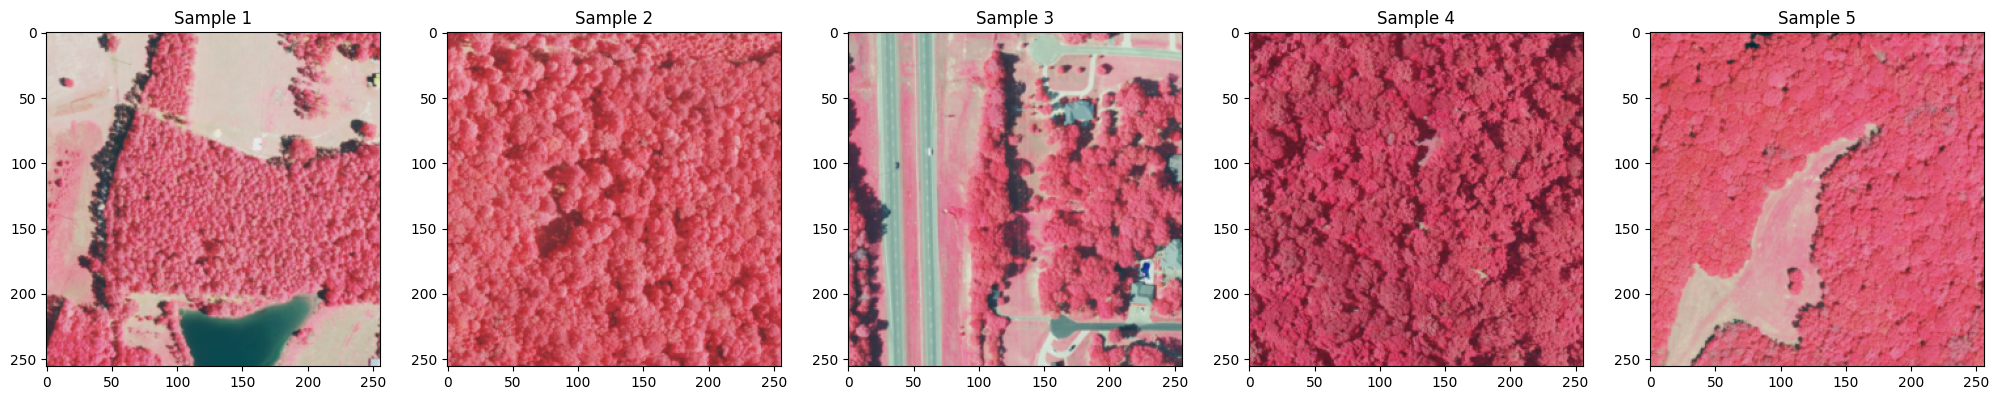

In [2]:
class BYOLDataset(torch.utils.data.Dataset):
    def __init__(self, raster_paths: Iterable[Union[str, Path]]):
        self.raster_paths = raster_paths

    def __len__(self):
        return len(self.raster_paths)

    def __getitem__(self, idx):
        raster_path = self.raster_paths[idx]
        with rio.open(raster_path) as src:
            # Read in color-infrared composites. NAIP data is stored as 
            # (R, G, B, NIR) bands, so we read in the NIR band first to get it 
            # in the right order for our model.
            img = src.read([4, 1, 2]) 
        
        # Normalize to [0, 1] - I used to do standardize to zero mean and one 
        # standard devitation (as seen in pretrain.py), but I don't anymore
        img = img.astype(np.float32) / 255.0 
        
        # now we can convert to a PyTorch tensor
        img = torch.from_numpy(img)
        
        return img


# now let's create a dataaset
raster_paths = list(Path('/scratch/dhester/mslc_data_v2/pretrain').glob('*.tif')) # get all tif files
raster_paths = np.random.choice(raster_paths, size=20000, replace=False) # randomly select 20,000 files
train_raster_paths = raster_paths[:19000] # use 19k for training
val_raster_paths = raster_paths[19000:] # use 1k for validation

dataset = BYOLDataset(train_raster_paths)
print(f'Number of training samples: {len(dataset)}')

test_img = dataset[0]
print(f'Image shape: {test_img.shape}') # should be (C, H, W)

fig, ax = plt.subplots(1, 5, figsize=(25, 5))
for i in range(5):
    ax[i].imshow(dataset[i].permute(1, 2, 0)) # permute to (H, W, C) for plotting
    ax[i].set_title(f'Sample {i+1}')

### Defining BYOL augmentations

The core idea behind BYOL is to train a model to learn to extract deep features from images that are invariant to complex transformations. PyTorch makes this very easy using `torchvision.transforms.v2` (which we have imported as `transforms`), which provides a convenient interface for defining complex data augmentation pipelines. 

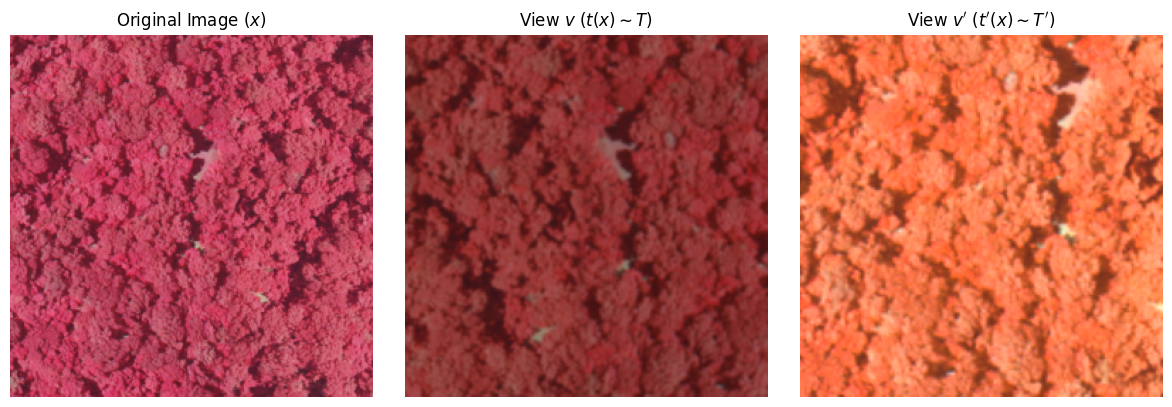

In [3]:
# base transform set (T)
T = transforms.Compose([
    transforms.RandomResizedCrop((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([transforms.ColorJitter(brightness=0.4, contrast=0.3, saturation=0.2, hue=0.1)], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.GaussianBlur(kernel_size=23, sigma=(0.1, 2.0)),
])

# alternative transform set (T')
T_prime = transforms.Compose([
    transforms.RandomResizedCrop((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([transforms.ColorJitter(brightness=0.4, contrast=0.3, saturation=0.2, hue=0.1)], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=23, sigma=(0.1, 2.0))], p=0.1),
    transforms.RandomSolarize(threshold=0.5, p=0.2),
])


x_test = dataset[3]
x1 = T(x_test)
x2 = T_prime(x_test)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(x_test.permute(1, 2, 0))
ax[0].set_title(r'Original Image ($x$)')
ax[1].imshow(x1.permute(1, 2, 0))
ax[1].set_title(r'View $v$ ($t(x) \sim T$)')
ax[2].imshow(x2.permute(1, 2, 0))
ax[2].set_title(r'View $v^\prime$ ($t^\prime (x) \sim T^\prime $)')

for i in range(3):
    ax[i].axis('off')

fig.tight_layout()
plt.show()

## Model configurations

### Online and target networks

BYOL uses two related but distinct networks during training: an online network (that we will eventually use for downstream tasks) and a target network (which provides the "signal" for the online network to learn from). The online network consists of an image encoder ($f_\theta$; e.g., a ConvNeXt model in this example), a projection head ($g_\theta$), and a subsequent prediction head ($q_\theta$). The target network is similar(image encoder $f_\xi$ and projection head $g_\xi$), but lacks the final prediction head. The target network begins its life as a copy of the online network.

![BYOL architecture](https://raw.githubusercontent.com/deepmancer/byol-pytorch/main/images/Byol.jpg)

In [4]:
class MLPHead(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int=4096, output_dim: int=256):
        super(MLPHead, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

f_theta = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1) # starting with a pre-trained model here
f_theta.classifier = nn.Flatten() # remove the classifier head, replace it with a flattening layer to get the feature representation
g_theta = MLPHead(input_dim=768)
q_theta = MLPHead(input_dim=256)

# create the target network by copying the online network (sans the predictor head)
f_xi = deepcopy(f_theta)
g_xi = deepcopy(g_theta)

# disable gradients for target network
for param in f_xi.parameters():
    param.requires_grad = False
for param in g_xi.parameters():
    param.requires_grad = False


# move to GPU (if applicable)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
f_theta = f_theta.to(device)
g_theta = g_theta.to(device)
q_theta = q_theta.to(device)
f_xi = f_xi.to(device)
g_xi = g_xi.to(device)

### Loss function and optimization

Like contrastive SSL methods, BYOL uses what is effectively a cosine similarity loss function to maximize the similarity between the online network's predictions and the target network's projections.

During training, we actually calculate the loss twice during each forward pass: once for the online network's prediction of $v$ compared to the target network's projection of $v^\prime$ (i.e., $q_\theta(g_\theta(f_\theta(v)))$ vs. $g_\xi(f_\xi(v^\prime))$), and once for the online network's prediction of $v^\prime$ compared to the target network's projection of $v$ (i.e., $q_\theta(g_\theta(f_\theta(v^\prime)))$ vs. $g_\xi(f_\xi(v))$).

In [5]:
def byol_loss(p: torch.Tensor, z: torch.Tensor) -> torch.Tensor:
    p = F.normalize(p, dim=1)
    z = F.normalize(z, dim=1)
    return 2 - 2 * (p * z).sum(dim=1).mean()

Now we can start setting up the standard neural network training components, including the optimizer and learning rate scheduler. It's good practice to use some form of learning rate warmup for the first few epochs of training to help stabilize training, then use some form of decaying learning rate schedule for the remainder of training (e.g., annealing cosine schedule).

One of the advantages of BYOL over other contrastive methods (like SimCLR) is that the entire batch does not need to loaded into memory at once, since training doesn't depend on a large number of negative samples. This means that we can use gradient accumulation to simulate a larger batch size than what would fit in memory, which can help to stabilize training and improve performance. 

Often, when using self-supervised learning, more epochs of training are often needed to achieve good performance. In this example, we set `TOTAL_EPOCHS = 100`, but don't be afraid to scale up to 300 or more epochs if you have the computational resources to do so.

In [6]:
LR = 1e-3
WARMUP_EPOCHS = 10
TOTAL_EPOCHS = 100 
BATCH_SIZE = 64
GRAD_ACCUM_STEPS = 4 # effective batch size will be BATCH_SIZE * GRAD_ACCUM_STEPS. 

# The original BYOL implementation uses LARS optimizer, but AdamW works just fine for our purposes
optimizer = torch.optim.AdamW(list(f_theta.parameters()) + list(g_theta.parameters()) + list(q_theta.parameters()), lr=LR)

# Use linear warmup for the first 10 epochs, then cosine annealing for the remaining epochs
warmup_scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=1 / WARMUP_EPOCHS, total_iters=WARMUP_EPOCHS-1)
main_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=TOTAL_EPOCHS - WARMUP_EPOCHS)
scheduler = torch.optim.lr_scheduler.SequentialLR(optimizer, schedulers=[warmup_scheduler, main_scheduler], milestones=[WARMUP_EPOCHS-1])

# Create a dataloader for our dataset
dataloader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

# We will use autocast for mixed precision training as well for faster training on GPU
scaler = torch.amp.GradScaler(device.type)
autocast_context = torch.amp.autocast(device.type)

One key hyperparameter specific to BYOL is the momentum parameter $\tau$. This controls how much influence the online network's new parameters have when updating the target network's parameters. Ideally, the target network should serve as a "moving target" for the online network to learn from. If we set $\tau=0$, then the target network simply directly copies the online network's parameters at each training step, which means the online network is attempting to learn from a network that is the same as itself, leading to degenerate solutions. On the other hand, at $\tau=1$, the target network's parameters are never updated, which means the online network is attempting to learn from a static target (which itself is effectively a random network at the start of training).

In practice, $\tau$ is set to a value close to 1 (e.g., $\tau_\text{base} = 0.996$) at the beginning of training and is increased over the course of training: as such, the target network will stabilize over the course of training. The original BYOL paper has some insights into the implications of varying $\tau$ and its relationship to what the authors describe as enabling the "near-optimal predictor" that is critical to BYOL's success. 

In [7]:
TAU_BASE = 0.996

# sometimes this is changed by total steps instead of epochs, but epochs is fine for our purposes
def get_tau(epoch: int, total_epochs: int=TOTAL_EPOCHS, tau_base: float=TAU_BASE) -> float:
    return 1 - (1 - tau_base) * (np.cos(np.pi * epoch / total_epochs) + 1) / 2

## Training loop

Now we can put everything together in the training loop. Each training step comprises the following actions:

1. Augment the input image twice to create two views of the same image (i.e., $v$ and $v^\prime$).
2. Pass both views through the online network to get the predictions (i.e., $q_\theta(g_\theta(f_\theta(v)))$ and $q_\theta(g_\theta(f_\theta(v^\prime)))$).
3. Pass both views through the target network to get the projections (i.e., $g_\xi(f_\xi(v))$ and $g_\xi(f_\xi(v^\prime))$.
4. Calculate the loss using the BYOL loss function, which compares the online network's predictions to the target network's projections.
5. Backpropagate the loss and update the online network's parameters using the optimizer.
6. Update the target network's parameters using the momentum update rule.

In [8]:
losses = []
    
for epoch in range(TOTAL_EPOCHS):
    
    with tqdm(total=len(dataloader), desc=f'Epoch {epoch+1}/{TOTAL_EPOCHS}', leave=False) as pbar:
        
        epoch_losses = []
        tau = get_tau(epoch) # get the momentum parameter for this epoch
        lr = optimizer.param_groups[0]['lr'] # get the current learning rate for logging purposes
        
        for i, x in enumerate(dataloader):
            
            # augment the image to get the two views
            v = T(x).to(device)
            v_prime = T_prime(x).to(device)
            
            with autocast_context:
                # pass the views through the online network
                q = q_theta(g_theta(f_theta(v)))
                q_prime = q_theta(g_theta(f_theta(v_prime)))
                
                # now pass them through the target network to get the "predicted" representations.
                with torch.no_grad(): # No need for gradients here
                    z = g_xi(f_xi(v))
                    z_prime = g_xi(f_xi(v_prime))
            
                # calculate the loss
                loss = byol_loss(q, z_prime) + byol_loss(q_prime, z)
            
            # backpropagate the loss with scaling to prevent underflow
            scaler.scale(loss).backward() 
            epoch_losses.append(loss.item())
            
            # gradient accumulation step: only update the online network's parameters every GRAD_ACCUM_STEPS steps
            if (i + 1) % GRAD_ACCUM_STEPS == 0:
                scaler.step(optimizer) # update the online network's parameters
                scaler.update()
                optimizer.zero_grad()
                
                # update the target network's parameters using the momentum update rule
                with torch.no_grad():
                    # update f_xi using t_thetas parameters
                    for param_theta, param_xi in zip(f_theta.parameters(), f_xi.parameters()):
                        param_xi.data = tau * param_xi.data + (1 - tau) * param_theta.data
                    # now do the same for g_xi
                    for param_theta, param_xi in zip(g_theta.parameters(), g_xi.parameters()):
                        param_xi.data = tau * param_xi.data + (1 - tau) * param_theta.data
            
            # Update the progress bar with the current loss, learning rate, and tau value
            pbar.set_postfix({'loss': np.mean(epoch_losses), 'lr': lr, 'tau': tau})
            pbar.update(1)
        
        # end of epoch, step the learning rate scheduler
        scheduler.step()
        losses.append(np.mean(epoch_losses))

Epoch 1/100:   0%|          | 0/296 [00:00<?, ?it/s]

Epoch 2/100:   0%|          | 0/296 [00:00<?, ?it/s]

Epoch 3/100:   0%|          | 0/296 [00:00<?, ?it/s]

Epoch 4/100:   0%|          | 0/296 [00:00<?, ?it/s]

Epoch 5/100:   0%|          | 0/296 [00:00<?, ?it/s]

...

Epoch 96/100:   0%|          | 0/296 [00:00<?, ?it/s]

Epoch 97/100:   0%|          | 0/296 [00:00<?, ?it/s]

Epoch 98/100:   0%|          | 0/296 [00:00<?, ?it/s]

Epoch 99/100:   0%|          | 0/296 [00:00<?, ?it/s]

Epoch 100/100:   0%|          | 0/296 [00:00<?, ?it/s]

In [9]:
torch.save({
    'f_theta': f_theta.state_dict(),
    'g_theta': g_theta.state_dict(),
    'q_theta': q_theta.state_dict(),
    'f_xi': f_xi.state_dict(),
    'g_xi': g_xi.state_dict(),
}, 'byol_pretrained.pth')

## Examining the results

Ideally, after trianing, $f_\theta$ is transferred to a downstream task (e.g., land cover classification) and fine-tuned on some labelled data. However, we can get a preliminary sense of the quality of extracted features by looking at the resulting embeddings on some held-out validation data. We will compare our model to an ImageNet-pretrained model and a randomly initialized model to see if our BYOL pretraining has yielded in more meaningful representations for our data.

### PCA

Ideally, embeddings learned through self-supervised learning should capture meaningful structure in the data such that the embedding space has rich, disentangled representations of the underlying data. One way to visualize this is to see how linearly reducible the embedding space is. Embeddings that are entangled will often be able to be well-represented with a handful of principal components, while embeddings that are more uniformly distributed will require more principal components to capture the same amount of variance. That is to say that better representations should require more principal components to capture the same amount of variance compared to worse representations.

We can see this by plotting the cumulative explained variance as a function of the number of principal components. If the curve rises sharply and then plateaus, this suggests that the embedding space is entangled and can be well-represented with a few principal components (and thus, bad). If the curve rises more gradually, this suggests that the embedding space is more uniformly distributed and requires more principal components to capture the same amount of variance.

Extracting embeddings:   0%|          | 0/16 [00:00<?, ?it/s]

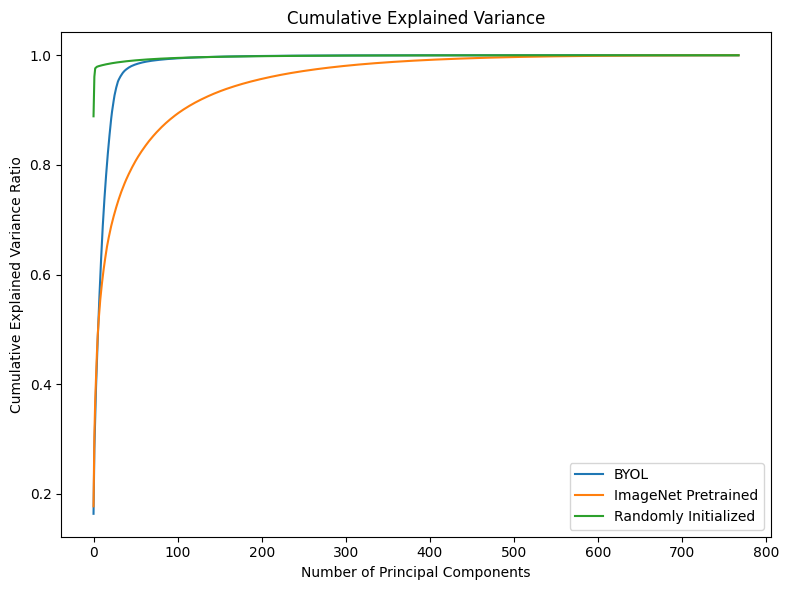

In [10]:
from sklearn.decomposition import PCA

f_inet = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
f_inet.classifier = nn.Flatten() # remove the classifier head, replace it with a flattening layer to get the feature representation
f_inet = f_inet.to(device)

f_random = convnext_tiny()
f_random.classifier = nn.Flatten()
f_random = f_random.to(device)

byol_embeddings = []
inet_embeddings = []
rand_embeddings = []

val_dataset = BYOLDataset(val_raster_paths)
val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
for x in tqdm(val_dataloader, desc='Extracting embeddings'):
    x = x.to(device)
    with torch.no_grad():
        byol_emb = f_theta(x).cpu().numpy()
        inet_emb = f_inet(x).cpu().numpy()
        rand_emb = f_random(x).cpu().numpy()
    byol_embeddings.append(byol_emb)
    inet_embeddings.append(inet_emb)
    rand_embeddings.append(rand_emb)
    
byol_embeddings = np.concatenate(byol_embeddings, axis=0)
inet_embeddings = np.concatenate(inet_embeddings, axis=0)
rand_embeddings = np.concatenate(rand_embeddings, axis=0)

byol_pca = PCA().fit(byol_embeddings)
inet_pca = PCA().fit(inet_embeddings)
rand_pca = PCA().fit(rand_embeddings)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(np.cumsum(byol_pca.explained_variance_ratio_), label='BYOL')
ax.plot(np.cumsum(inet_pca.explained_variance_ratio_), label='ImageNet Pretrained')
ax.plot(np.cumsum(rand_pca.explained_variance_ratio_), label='Randomly Initialized')
ax.set_title('Cumulative Explained Variance')
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Explained Variance Ratio')
ax.legend()

fig.tight_layout()
plt.show()

### Embedding similarity analysis

Similarly, we can look at the distribution of pairwise cosine similarities between embeddings. If the distribution is sharply peaked around 1, this suggests that the embedding space is entangled and all embeddings are very similar to each other (and thus, bad). If the distribution is more spread out, this suggests that the embedding space is more uniformly distributed and has more meaningful structure (and thus, good).

Text(0, 0.5, 'Frequency')

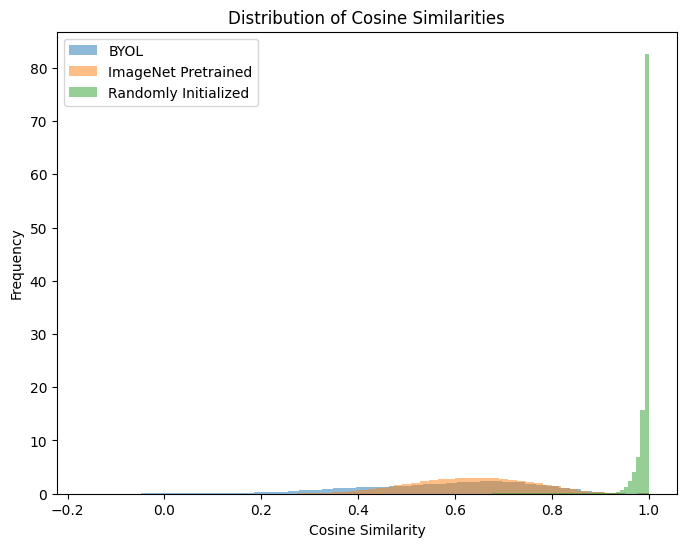

In [11]:
byol_sims = (np.dot(byol_embeddings, byol_embeddings.T) / (np.linalg.norm(byol_embeddings, axis=1, keepdims=True) * np.linalg.norm(byol_embeddings, axis=1, keepdims=True).T)).flatten()
inet_sims = (np.dot(inet_embeddings, inet_embeddings.T) / (np.linalg.norm(inet_embeddings, axis=1, keepdims=True) * np.linalg.norm(inet_embeddings, axis=1, keepdims=True).T)).flatten()
rand_sims = (np.dot(rand_embeddings, rand_embeddings.T) / (np.linalg.norm(rand_embeddings, axis=1, keepdims=True) * np.linalg.norm(rand_embeddings, axis=1, keepdims=True).T)).flatten()

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.hist(byol_sims, bins=50, alpha=0.5, density=True, label='BYOL')
ax.hist(inet_sims, bins=50, alpha=0.5, density=True, label='ImageNet Pretrained')
ax.hist(rand_sims, bins=50, alpha=0.5, density=True, label='Randomly Initialized')
ax.legend()
ax.set_title('Distribution of Cosine Similarities')
ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('Frequency')